# How similar are the HRFs in a Sobol library?

The default library samples double-gamma parameters with a scrambled Sobol sequence.
Parameter-space coverage does not guarantee waveform-space coverage: different parameter
combinations can produce nearly identical kernels, and a selection among near-duplicates
is a coin flip. This notebook measures that directly.

1. Build a very large Sobol candidate set (the full pairwise similarity matrix is cheap up to
   about 16k candidates: a 16k × 16k float32 matrix is 1 GB and takes under a second).
2. Compute two similarity measures between every pair of sampled kernels:
   **cosine similarity of the raw curves** (the measure used in the recovery-test review) and
   **Pearson correlation** (cosine after removing each curve's mean, which discounts the shared
   positive bump).
3. Plot the distribution of all pairwise similarities and, more usefully for pruning, each
   candidate's **nearest-neighbour** similarity.
4. Test the pruning idea: starting from canonical SPM, greedily add the candidate least similar to
   the set chosen so far (farthest-point selection) and record the maximum pairwise similarity
   achieved as the library grows. Reading that curve one way gives "the most dissimilar library
   of size k"; reading it the other way gives "the library size needed for a maximum similarity".

Nothing here changes the package; it only measures.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from boldtailor.hrf_library import sobol_hrf_library

N_SAMPLES = 16384  # must be a power of two; the library adds canonical SPM as id 0
SEED = 0

library = sobol_hrf_library(n_samples=N_SAMPLES, seed=SEED)
curves = library.curves.astype(np.float32)  # (n_candidates, n_times) sampled at 0.1 s, peak one
times = library.times
print(curves.shape, f"{times[-1]:.1f} s grid")

(16385, 360) 35.9 s grid


## Similarity measures

Both measures are computed on the 0.1 s curves. Cosine similarity compares the raw waveforms;
Pearson correlation first removes each curve's mean. Because every double-gamma kernel shares a
large positive lobe, raw cosine is dominated by that lobe and sits close to one for almost any
pair; Pearson is more sensitive to differences in timing and undershoot.

In [2]:
def unit_rows(matrix):
    return matrix / np.linalg.norm(matrix, axis=1, keepdims=True)


def similarity_matrix(matrix, *, center):
    rows = matrix - matrix.mean(axis=1, keepdims=True) if center else matrix
    rows = unit_rows(rows.astype(np.float32))
    return np.clip(rows @ rows.T, -1.0, 1.0)


def pairwise(values):
    return values[np.triu_indices(len(values), 1)]


def nearest_neighbour(values):
    off_diagonal = np.where(np.eye(len(values), dtype=bool), -np.inf, values)
    return off_diagonal.max(axis=1)


cosine = similarity_matrix(curves, center=False)
pearson = similarity_matrix(curves, center=True)
measures = {"cosine (raw curves)": cosine, "Pearson (centred curves)": pearson}

summary = pd.DataFrame(
    {
        name: {
            "pairs": len(pairwise(s)),
            "median pairwise": np.median(pairwise(s)),
            "99th pct pairwise": np.quantile(pairwise(s), 0.99),
            "median nearest neighbour": np.median(nearest_neighbour(s)),
            "min nearest neighbour": nearest_neighbour(s).min(),
            "fraction with NN > 0.99": (nearest_neighbour(s) > 0.99).mean(),
            "fraction with NN > 0.995": (nearest_neighbour(s) > 0.995).mean(),
        }
        for name, s in measures.items()
    }
)
summary.round(4)

,cosine (raw curves),Pearson (centred curves)
pairs,1.342259e+08,1.342259e+08
median pairwise,9.000000e-01,8.908000e-01
99th pct pairwise,9.964000e-01,9.965000e-01
median nearest neighbour,9.996000e-01,9.996000e-01
min nearest neighbour,9.857000e-01,9.870000e-01
fraction with NN > 0.99,9.999000e-01,9.999000e-01
fraction with NN > 0.995,9.985000e-01,9.990000e-01


## Distribution of all pairwise similarities

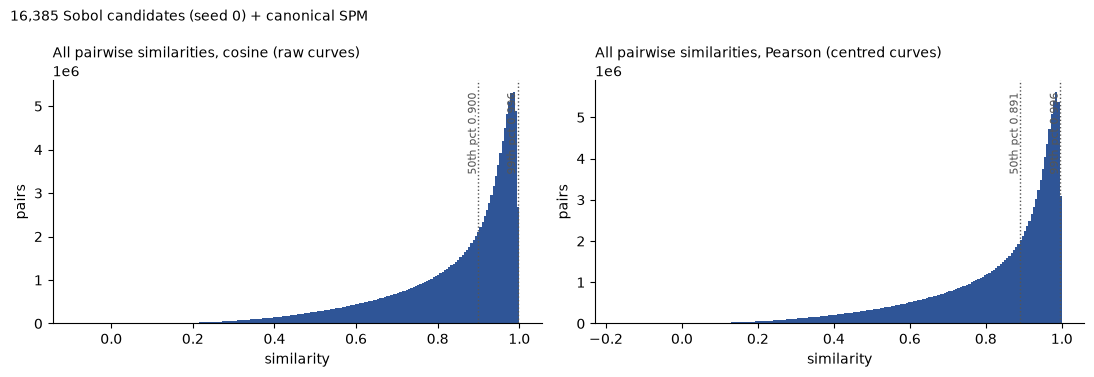

In [3]:
INK = "#2F5597"  # single hue: one series per panel
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (name, s) in zip(axes, measures.items()):
    values = pairwise(s)
    ax.hist(values, bins=200, color=INK, linewidth=0)
    for q in (0.5, 0.99):
        v = np.quantile(values, q)
        ax.axvline(v, color="#555555", linewidth=1, linestyle=":")
        ax.text(v, ax.get_ylim()[1] * 0.95, f"{int(q*100)}th pct {v:.3f}", rotation=90,
                va="top", ha="right", fontsize=8, color="#555555")
    ax.set_title(f"All pairwise similarities, {name}", fontsize=10, loc="left")
    ax.set_xlabel("similarity")
    ax.set_ylabel("pairs")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(f"{curves.shape[0]:,} Sobol candidates (seed {SEED}) + canonical SPM", fontsize=10, x=0.01, ha="left")
fig.tight_layout()

## Nearest-neighbour similarity

For pruning, the quantity that matters is not the typical pair but each candidate's closest
neighbour: a library is only as distinct as its most similar pair. The current default
(512 Sobol samples, seed 0) is overlaid for reference.

,16k candidates,"default 512, cosine","default 512, Pearson"
count,16385.0000,513.0000,513.0000
mean,0.9995,0.9978,0.9979
std,0.0006,0.0022,0.0021
min,0.9857,0.9801,0.9822
1%,0.9973,0.9876,0.9877
50%,0.9996,0.9985,0.9985
99%,0.9999,0.9998,0.9998
max,1.0000,0.9999,0.9999


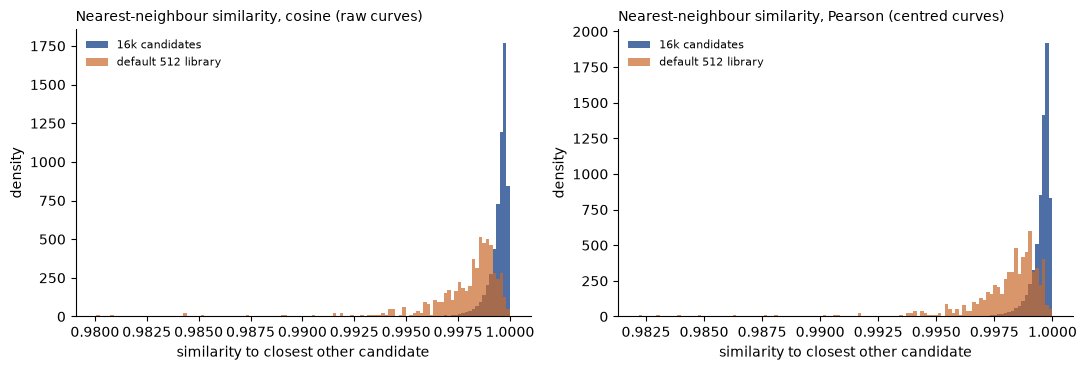

In [4]:
default_library = sobol_hrf_library(n_samples=512, seed=SEED)
default_curves = default_library.curves.astype(np.float32)

SERIES = {"16k candidates": "#2F5597", "default 512 library": "#C96A2B"}  # fixed order
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
for ax, (name, center) in zip(axes, [("cosine (raw curves)", False), ("Pearson (centred curves)", True)]):
    big = nearest_neighbour(similarity_matrix(curves, center=center))
    small = nearest_neighbour(similarity_matrix(default_curves, center=center))
    lo = min(big.min(), small.min())
    bins = np.linspace(lo, 1.0, 120)
    ax.hist(big, bins=bins, density=True, color=SERIES["16k candidates"], alpha=0.85, linewidth=0, label="16k candidates")
    ax.hist(small, bins=bins, density=True, color=SERIES["default 512 library"], alpha=0.7, linewidth=0, label="default 512 library")
    ax.set_title(f"Nearest-neighbour similarity, {name}", fontsize=10, loc="left")
    ax.set_xlabel("similarity to closest other candidate")
    ax.set_ylabel("density")
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

pd.DataFrame({
    "16k candidates": pd.Series(nearest_neighbour(cosine)).describe(percentiles=[0.01, 0.5, 0.99]),
    "default 512, cosine": pd.Series(nearest_neighbour(similarity_matrix(default_curves, center=False))).describe(percentiles=[0.01, 0.5, 0.99]),
    "default 512, Pearson": pd.Series(nearest_neighbour(similarity_matrix(default_curves, center=True))).describe(percentiles=[0.01, 0.5, 0.99]),
}).round(4)

## Pruning by farthest-point selection

Greedy maximin: start with canonical SPM (id 0); at each step add the candidate whose maximum
similarity to the chosen set is smallest. The curve records, after each addition, the largest
pairwise similarity in the chosen set. It answers both questions at once: the most dissimilar
library of a given size, and the size at which a desired maximum similarity is no longer
attainable from this candidate pool.

,cosine (raw curves),Pearson (centred curves)
library size,,
64,0.9777,0.9794
128,0.9864,0.9870
256,0.9914,0.9916
512,0.9945,0.9947
1024,0.9964,0.9967
2048,0.9978,0.9979


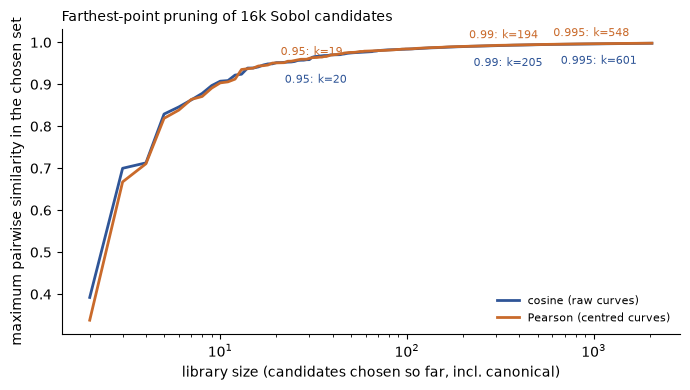

In [5]:
def farthest_point_order(similarity, *, start=0, k=None):
    n = len(similarity)
    k = n if k is None else k
    chosen = [start]
    closest = similarity[start].copy()
    closest[start] = np.inf
    achieved = []
    for _ in range(k - 1):
        nxt = int(np.argmin(closest))
        chosen.append(nxt)
        achieved.append(float(closest[nxt]))  # max similarity between the new member and the set
        closest = np.maximum(closest, similarity[nxt])
        closest[chosen] = np.inf
    return np.array(chosen), np.array(achieved)


K_MAX = 2048
curves_by_measure = {}
fig, ax = plt.subplots(figsize=(7, 4))
for (name, s), color in zip(measures.items(), SERIES.values()):
    order, achieved = farthest_point_order(s, k=K_MAX)
    curves_by_measure[name] = (order, achieved)
    sizes = np.arange(2, K_MAX + 1)
    ax.plot(sizes, achieved, color=color, linewidth=2, label=name)
    for target in (0.95, 0.99, 0.995):
        hit = np.argmax(achieved > target)
        if achieved[hit] > target:
            ax.annotate(f"{target}: k={sizes[hit]}", (sizes[hit], target), fontsize=8,
                        textcoords="offset points", xytext=(6, -14 if name.startswith("cos") else 6), color=color)
ax.set_xscale("log")
ax.set_xlabel("library size (candidates chosen so far, incl. canonical)")
ax.set_ylabel("maximum pairwise similarity in the chosen set")
ax.set_title("Farthest-point pruning of 16k Sobol candidates", fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

pd.DataFrame({name: dict(zip([64, 128, 256, 512, 1024, 2048], [achieved[k - 2] for k in (64, 128, 256, 512, 1024, 2048)]))
              for name, (order, achieved) in curves_by_measure.items()}).rename_axis("library size").round(4)

## What do these similarity values look like?

The most similar and the least similar pairs in the default 512 library, to calibrate the numbers.

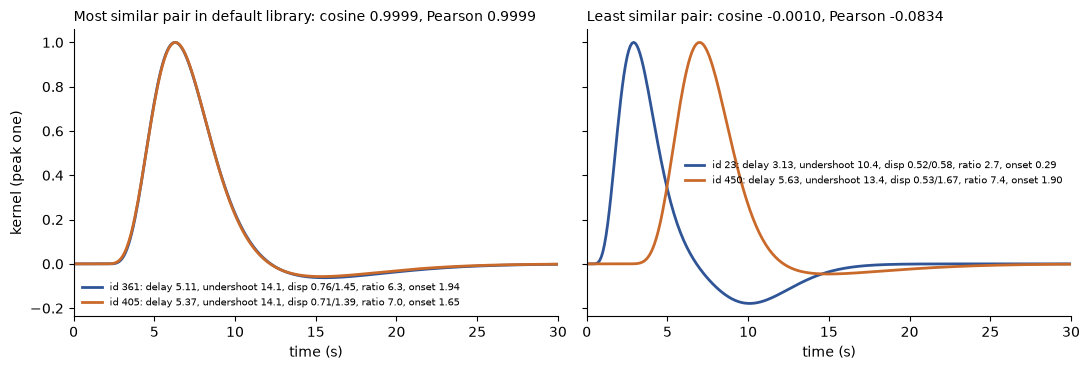

In [6]:
def show_pair(ax, lib, i, j, label):
    for idx, color in zip((i, j), SERIES.values()):
        p = lib.candidates[idx].parameters
        ax.plot(lib.times, lib.curves[idx], color=color, linewidth=2,
                label=f"id {idx}: delay {p[0]:.2f}, undershoot {p[1]:.1f}, disp {p[2]:.2f}/{p[3]:.2f}, ratio {p[4]:.1f}, onset {p[5]:.2f}")
    ax.set_title(label, fontsize=10, loc="left")
    ax.set_xlabel("time (s)")
    ax.set_xlim(0, 30)
    ax.legend(frameon=False, fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)


small_cos = similarity_matrix(default_curves, center=False)
off = np.where(np.eye(len(small_cos), dtype=bool), -np.inf, small_cos)
i, j = np.unravel_index(np.argmax(off), off.shape)
a, b = np.unravel_index(np.argmin(np.where(np.eye(len(small_cos), dtype=bool), np.inf, small_cos)), off.shape)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
show_pair(axes[0], default_library, int(i), int(j), f"Most similar pair in default library: cosine {small_cos[i, j]:.4f}, Pearson {similarity_matrix(default_curves, center=True)[i, j]:.4f}")
show_pair(axes[1], default_library, int(a), int(b), f"Least similar pair: cosine {small_cos[a, b]:.4f}, Pearson {similarity_matrix(default_curves, center=True)[a, b]:.4f}")
axes[0].set_ylabel("kernel (peak one)")
fig.tight_layout()

## Sampling in timing space instead

`timing_hrf_library` samples the **realized** peak time, response FWHM, trough time, undershoot FWHM, and
trough depth of the combined curve, with onset fixed; each point is converted to SPM
parameters by numerical refinement (`spm_parameters_from_realized`), and points no double gamma
can realize are skipped (`origin["rejected"]`). Because onset and response delay no longer trade
off into the same peak time, the sampler should not oversample a few waveforms. The refinement
costs about 10 ms per candidate, so the timing-space pool here is 4,096 rather than 16k; its
farthest-point curve is compared with the gamma-box pool over the same library sizes.

timing pool: 4,097 candidates, 2963 infeasible Sobol points skipped


,gamma-box pool,timing-space pool,Sobol 512 NN median,timing 512 NN median
library size,,,,
64,0.9777,0.9310,NaN,NaN
128,0.9864,0.9569,NaN,NaN
256,0.9914,0.9724,NaN,NaN
512,0.9945,0.9830,0.9985,0.9914
1024,0.9964,0.9899,NaN,NaN


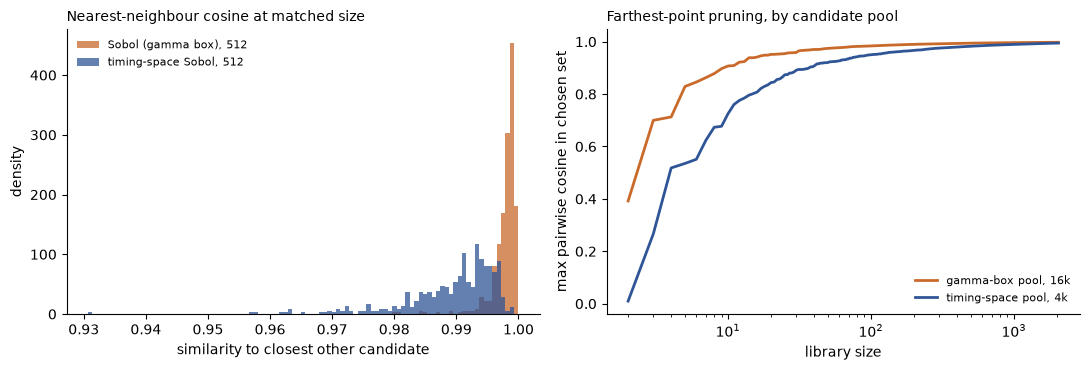

In [7]:
from boldtailor.hrf_library import timing_hrf_library

timing_default = timing_hrf_library(n_samples=512, seed=SEED)
TIMING_POOL = 4096
timing_pool = timing_hrf_library(n_samples=TIMING_POOL, seed=SEED)
print(f"timing pool: {len(timing_pool.candidates):,} candidates, {timing_pool.origin['rejected']} infeasible Sobol points skipped")
timing_curves = timing_pool.curves.astype(np.float32)
timing_cosine = similarity_matrix(timing_curves, center=False)

LIBRARIES = {"Sobol (gamma box), 512": default_curves, "timing-space Sobol, 512": timing_default.curves.astype(np.float32)}
COLORS = {"Sobol (gamma box), 512": "#C96A2B", "timing-space Sobol, 512": "#2F5597"}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
nn = {name: nearest_neighbour(similarity_matrix(c, center=False)) for name, c in LIBRARIES.items()}
bins = np.linspace(min(v.min() for v in nn.values()), 1.0, 100)
for name, values in nn.items():
    axes[0].hist(values, bins=bins, density=True, color=COLORS[name], alpha=0.75, linewidth=0, label=name)
axes[0].set_title("Nearest-neighbour cosine at matched size", fontsize=10, loc="left")
axes[0].set_xlabel("similarity to closest other candidate"); axes[0].set_ylabel("density")
axes[0].legend(frameon=False, fontsize=8); axes[0].spines[["top", "right"]].set_visible(False)

order, achieved = farthest_point_order(timing_cosine, k=K_MAX)
sizes = np.arange(2, K_MAX + 1)
axes[1].plot(sizes, curves_by_measure["cosine (raw curves)"][1], color=COLORS["Sobol (gamma box), 512"], linewidth=2, label="gamma-box pool, 16k")
axes[1].plot(sizes, achieved, color=COLORS["timing-space Sobol, 512"], linewidth=2, label=f"timing-space pool, {TIMING_POOL // 1024}k")
axes[1].set_xscale("log"); axes[1].set_xlabel("library size"); axes[1].set_ylabel("max pairwise cosine in chosen set")
axes[1].set_title("Farthest-point pruning, by candidate pool", fontsize=10, loc="left")
axes[1].legend(frameon=False, fontsize=8); axes[1].spines[["top", "right"]].set_visible(False)
fig.tight_layout()

pd.DataFrame({
    "gamma-box pool": {k: curves_by_measure["cosine (raw curves)"][1][k - 2] for k in (64, 128, 256, 512, 1024)},
    "timing-space pool": {k: achieved[k - 2] for k in (64, 128, 256, 512, 1024)},
    "Sobol 512 NN median": {512: float(np.median(nn["Sobol (gamma box), 512"]))},
    "timing 512 NN median": {512: float(np.median(nn["timing-space Sobol, 512"]))},
}).rename_axis("library size").round(4)

## Observations (seed 0, 16,384 Sobol samples + canonical)

- **Raw-curve cosine barely separates HRFs.** Among 134 million pairs the median cosine is
  0.900 and the 99th percentile 0.996, but the quantity that matters for a library, each
  candidate's nearest neighbour, has median 0.9996 and minimum 0.986: 99.9 % of candidates have a
  neighbour above 0.99 and 99.85 % above 0.995. The 0.995 pair that caused a coin flip in the
  recovery test is typical of the pool, not an outlier. In the default 512 library the median
  nearest-neighbour cosine is 0.9985 and the most similar pair is at 0.9999.
- **Pearson correlation does not help.** Centring the curves changes the numbers in the third
  decimal only; the shared positive lobe is not what makes pairs similar. Pairs are similar
  because different parameter combinations give the same waveform.
- **The most similar pair in the default library shows why**: response delay 5.11 s with onset
  1.94 s versus delay 5.37 s with onset 1.65 s. Delay and onset trade off almost exactly into
  the same peak time, and dispersion/ratio differences are nearly invisible on the 0.1 s grid.
  Sampling the gamma parameters uniformly therefore oversamples a few waveform shapes.
- **Farthest-point pruning works but is expensive in waveform similarity.** From this pool the
  most dissimilar library of size 512 still has a maximum pairwise cosine of 0.9945; reaching a
  maximum of 0.99 allows about 200 candidates, 0.95 about 20. A cap of 0.995 is reached at a
  size of about 550 to 600, so the default size cannot be made much more distinct than 0.995
  with raw cosine as the criterion.

**Timing-space sampling (realized peak time, response FWHM, trough time, undershoot FWHM,
depth; default box peak 2.5-8.5 s, response FWHM 2-6.5 s, trough 8-19 s, undershoot FWHM 4-10 s,
depth 0.05-0.4; pool of 4,096 with 42 % of Sobol points unrealizable and skipped).**
Farthest-point selection from this pool reaches a maximum pairwise cosine of 0.931 at 64
candidates, 0.972 at 256 and 0.983 at 512, versus 0.978, 0.991 and 0.995 from the 16k
gamma-parameter pool; at the default size the median nearest-neighbour cosine is 0.9914 (timing
space) versus 0.9985 (gamma box). With the earlier, narrower box (peak 3.5-7.5 s, FWHM 3-6 s,
trough 11-18 s, undershoot FWHM 6-12 s) the same sampler gave 0.992 at 512 and a median nearest
neighbour of 0.9957, so the gain comes from the wider ranges rather than from the sampler: the
accepted set is uniform over the feasible part of whatever box is requested, and the rejection
rate is unchanged at about 40 %. Pruning afterwards remains available if a tighter cap is
wanted at a given size.

Implications for the next step:

1. Cosine or correlation on the full curve is the wrong yardstick for "too similar": the
   selection objective compares *predicted BOLD* for a given design, and small timing shifts
   matter more than curve-wide similarity suggests. A design-aware distance (correlation of the
   two kernels' predicted responses for the study's event timing, or of their nilearn regressors)
   would be a better pruning criterion, and could be computed once per study.
2. Sample in a less degenerate parameterization (peak time, FWHM, undershoot time and ratio)
   so the box itself does not oversample identical waveforms, then prune.
3. Compare three constructions at matched size (Sobol; Sobol + farthest-point; timing-space
   grid) by their recovery rate in the simulation of `tests/test_recovery.py` rather than by a
   similarity cap alone.
